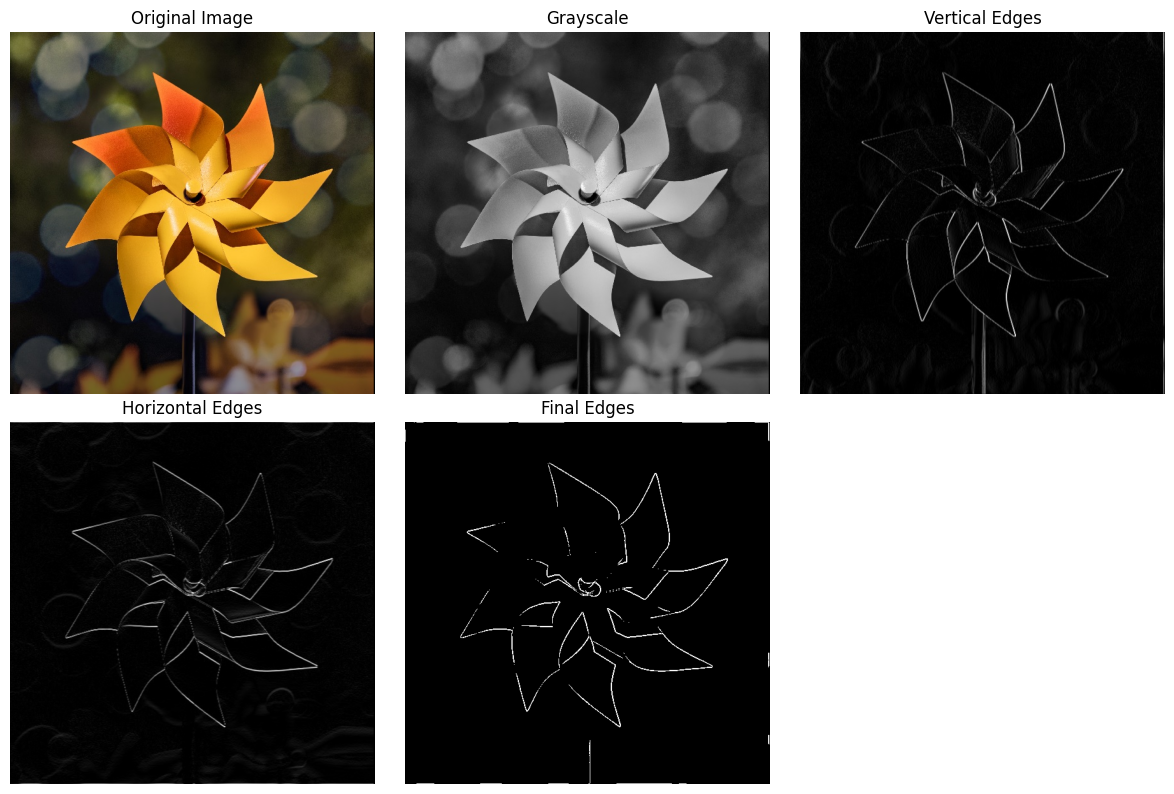

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# Loading the image
image = Image.open("/content/sample_data/Sample.png")
image = np.array(image)

# Grayscale conversion

gray = (0.299 * image[:, :, 0] + 0.587 * image[:, :, 1] + 0.114 * image[:, :, 2])

gray = gray.astype(np.float32)

# Sobel kernels

Gx = np.array([  # Horizontl Kernel
    [-1,  0,  1],
    [-2,  0,  2],
    [-1,  0,  1]
])

Gy = np.array([  # Vertical Kernel
    [-1, -2, -1],
    [ 0,  0,  0],
    [ 1,  2,  1]
])


# Convolution function

def convolution(image, kernel):

    height, width = image.shape

    # Padding
    padded = np.pad(image, 1, mode="constant")

    result = np.zeros((height, width))

    # Moving the kernel across image
    for i in range(height):
        for j in range(width):

            # Current 3x3 region
            region = padded[i:i+3, j:j+3]

            # convolution
            result[i, j] = np.sum(region * kernel)

    return result

# Applying Sobel kernels

vertical_edges = convolution(gray, Gx)
horizontal_edges = convolution(gray, Gy)


# Calculate gradient

gradient = np.sqrt(vertical_edges ** 2 + horizontal_edges ** 2)

# Normalize

gradient = gradient / gradient.max() * 255
gradient = gradient.astype(np.uint8)

# Threshold

threshold = 110

edges = np.where(gradient > threshold, 255, 0)

# Results

plt.figure(figsize=(12, 8))

plt.subplot(2, 3, 1)
plt.imshow(image)
plt.title("Original Image")
plt.axis("off")

plt.subplot(2, 3, 2)
plt.imshow(gray, cmap="gray")
plt.title("Grayscale")
plt.axis("off")

plt.subplot(2, 3, 3)
plt.imshow(np.abs(vertical_edges), cmap="gray")
plt.title("Vertical Edges")
plt.axis("off")

plt.subplot(2, 3, 4)
plt.imshow(np.abs(horizontal_edges), cmap="gray")
plt.title("Horizontal Edges")
plt.axis("off")

plt.subplot(2, 3, 5)
plt.imshow(edges, cmap="gray")
plt.title("Final Edges")
plt.axis("off")

plt.tight_layout()
plt.show()

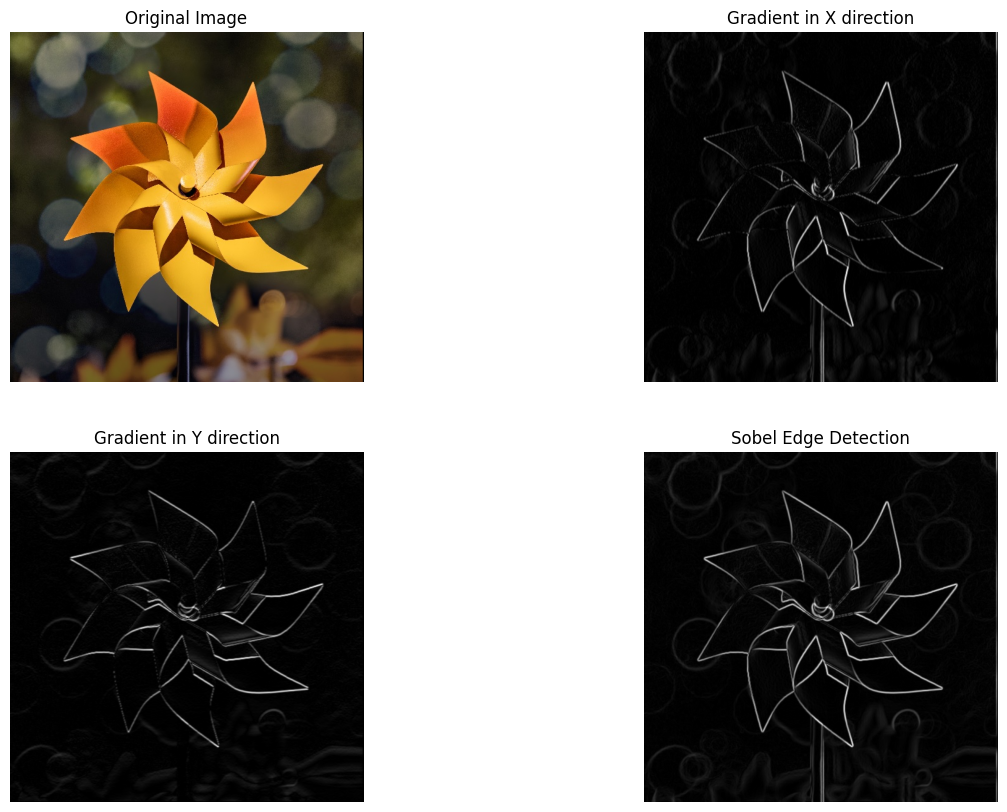

In [16]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load the image
image_path = '/content/sample_data/Sample.png'  # Replace with your image path
image = cv2.imread(image_path)

# Convert to grayscale
gray_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# Apply Gaussian smoothing (optional)
blurred_image = cv2.GaussianBlur(gray_image, (3, 3), 0)

# Sobel operators
Gx = cv2.Sobel(blurred_image, cv2.CV_64F, 1, 0, ksize=3)
Gy = cv2.Sobel(blurred_image, cv2.CV_64F, 0, 1, ksize=3)

# Gradient magnitude
G = np.sqrt(Gx**2 + Gy**2)

# Normalize to range 0-255
Gx = np.uint8(255 * np.abs(Gx) / np.max(Gx))
Gy = np.uint8(255 * np.abs(Gy) / np.max(Gy))
G = np.uint8(255 * G / np.max(G))

# Display the results
plt.figure(figsize=(15, 10))

# Original image
plt.subplot(2, 2, 1)
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.title('Original Image')
plt.axis('off')

# Gradient in X direction
plt.subplot(2, 2, 2)
plt.imshow(Gx, cmap='gray')
plt.title('Gradient in X direction')
plt.axis('off')

# Gradient in Y direction
plt.subplot(2, 2, 3)
plt.imshow(Gy, cmap='gray')
plt.title('Gradient in Y direction')
plt.axis('off')

# Edge-detected image
plt.subplot(2, 2, 4)
plt.imshow(G, cmap='gray')
plt.title('Sobel Edge Detection')
plt.axis('off')

plt.show()